# PINN to Solve Optimization Problems

**Tutorial:** Solving constrained optimisation problems by reformulating their KKT conditions as an IVP and solving it with Physics-Informed Neural Networks (PINNs) in JAX.

---

In [ ]:
# Install dependencies (Google Colab users)
!pip install requirements.txt

## 1. Mathematical Background

### 1.1 Optimization Problem

We consider the standard non-linear programming (NLP) problem:

$$\min_{x \in \mathbb{R}^n} \quad f(x)$$

$$\text{subject to} \quad h_i(x) = 0, \quad i = 1, \dots, p$$

$$\quad\quad\quad\quad\quad\;\; g_j(x) \le 0, \quad j = 1, \dots, m$$

The **Lagrangian** is:

$$L(x, \lambda, \mu) = f(x) + \lambda^\top h(x) + \mu^\top g(x)$$

### 1.2 KKT Conditions

At a local minimum $(x^*, \lambda^*, \mu^*)$:

1. **Stationarity**: $\nabla_x L = 0$
2. **Primal feasibility**: $h(x^*) = 0$, $g(x^*) \le 0$
3. **Dual feasibility**: $\mu^* \ge 0$
4. **Complementary slackness**: $\mu^*_j g_j(x^*) = 0$

### 1.3 IVP via Primal-Dual Gradient Flow

We embed the KKT system in a continuous-time ODE whose equilibrium is the KKT point:

$$\frac{dx}{dt} = -\nabla_x L(x, \lambda, \mu)$$

$$\frac{d\lambda}{dt} = h(x)$$

$$\frac{d\mu}{dt} = [g(x)]_+$$

With initial conditions $z(0) = z_0$, this is a well-posed **Initial Value Problem**.

### 1.4 PINN Approach

We parameterise the solution trajectory $z(t) = (x(t), \lambda(t), \mu(t))$ with a neural network $\hat{z}_\theta(t)$ and minimise:

$$\mathcal{L}(\theta) = \underbrace{\frac{1}{N}\sum_k \|\dot{\hat{z}}_\theta(t_k) - F(\hat{z}_\theta(t_k))\|^2}_{\mathcal{L}_{\text{ODE}}} + \underbrace{\|\hat{z}_\theta(0) - z_0\|^2}_{\mathcal{L}_{\text{IC}}}$$

The time derivative $\dot{\hat{z}}_\theta$ is computed **exactly** via `jax.grad`.

---
## 2. Toy Problem

$$\min_{x,y} \quad x^2 + y^2 \qquad \text{s.t.} \quad x + y = 1$$

Analytical solution: $x^* = y^* = 0.5$, $\lambda^* = -1$.

In [1]:
import jax
import jax.numpy as jnp

# ---- Problem definition ----

def objective(xy):
    """f(x, y) = x^2 + y^2"""
    x, y = xy[0], xy[1]
    return x**2 + y**2

def equality_constraint(xy):
    """h(x, y) = x + y - 1 = 0"""
    x, y = xy[0], xy[1]
    return x + y - 1.0

def lagrangian(xy, lam):
    """L(x, y, lam) = f(x, y) + lam * h(x, y)"""
    return objective(xy) + lam[0] * equality_constraint(xy)

# ---- Gradient-flow RHS ----

def primal_rhs(xy, lam):
    """dx/dt = -grad_x L"""
    return -jax.grad(lagrangian, argnums=0)(xy, lam)

def dual_rhs(xy):
    """dlambda/dt = h(x)"""
    return jnp.array([equality_constraint(xy)])

print("Problem functions defined.")

Problem functions defined.


---
## 3. Neural Network Architecture (Flax)

In [2]:
import flax.linen as nn
from typing import Sequence

class PINN(nn.Module):
    """Fully-connected network:  t  →  [x(t), y(t), lambda(t)]."""
    hidden_sizes: Sequence[int] = (32, 32, 32)

    @nn.compact
    def __call__(self, t):
        z = jnp.atleast_1d(t)
        for size in self.hidden_sizes:
            z = nn.Dense(size)(z)
            z = nn.tanh(z)
        z = nn.Dense(3)(z)   # [x, y, lambda]
        return z

model = PINN(hidden_sizes=(32, 32, 32))
print("Network architecture:")
print(model.tabulate(jax.random.PRNGKey(0), jnp.array(0.0)))

Network architecture:

                              PINN Summary                               
┏━━━━━━━━━┳━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ path    ┃ module ┃ inputs      ┃ outputs     ┃ params                 ┃
┡━━━━━━━━━╇━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│         │ PINN   │ float32[]   │ float32[3]  │                        │
├─────────┼────────┼─────────────┼─────────────┼────────────────────────┤
│ Dense_0 │ Dense  │ float32[1]  │ float32[32] │ bias: float32[32]      │
│         │        │             │             │ kernel: float32[1,32]  │
│         │        │             │             │                        │
│         │        │             │             │ 64 (256 B)             │
├─────────┼────────┼─────────────┼─────────────┼────────────────────────┤
│ Dense_1 │ Dense  │ float32[32] │ float32[32] │ bias: float32[32]      │
│         │        │             │             │ kernel: float32[32,32] │
│         │    

---
## 4. PINN Loss Function

In [3]:
from functools import partial

def pinn_loss(params, apply_fn, t_colloc, z0, w_ode=1.0, w_ic=10.0):
    """Total PINN loss = w_ode * L_ode + w_ic * L_ic."""

    def net(t):
        return apply_fn({"params": params}, t)

    dnet_dt_vec = jax.jacfwd(net)

    def ode_residual(t):
        z   = net(t)
        dz  = dnet_dt_vec(t).squeeze()
        xy  = z[:2]
        lam = z[2:3]
        rhs = jnp.concatenate([primal_rhs(xy, lam), dual_rhs(xy)])
        return dz - rhs

    residuals = jax.vmap(ode_residual)(t_colloc)
    L_ode = jnp.mean(residuals ** 2)

    z_pred_0 = net(jnp.array(0.0))
    L_ic = jnp.mean((z_pred_0 - z0) ** 2)

    return w_ode * L_ode + w_ic * L_ic

print("Loss function defined.")

Loss function defined.


---
## 5. Training Loop

In [4]:
import optax

# Hyper-parameters
T         = 5.0
N_COLLOC  = 100
N_EPOCHS  = 5000
LR        = 1e-3
SEED      = 42

# Initial conditions:  z(0) = [x0, y0, lambda0]
Z0 = jnp.array([0.0, 2.0, 0.0])

t_colloc = jnp.linspace(0.0, T, N_COLLOC)

# Initialise parameters
key = jax.random.PRNGKey(SEED)
params = model.init(key, jnp.array(0.0))["params"]

optimizer = optax.adam(LR)
opt_state = optimizer.init(params)

loss_and_grad = jax.jit(
    jax.value_and_grad(
        partial(pinn_loss, apply_fn=model.apply, t_colloc=t_colloc, z0=Z0)
    )
)

loss_history = []

for epoch in range(1, N_EPOCHS + 1):
    loss_val, grads = loss_and_grad(params)
    updates, opt_state = optimizer.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    loss_history.append(float(loss_val))
    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Loss {loss_val:.6e}")

print("\nTraining complete.")

Epoch   500 | Loss 4.016114e-03
Epoch  1000 | Loss 1.327781e-03
Epoch  1500 | Loss 7.146529e-04
Epoch  2000 | Loss 4.246458e-04
Epoch  2500 | Loss 3.316928e-04
Epoch  3000 | Loss 1.882346e-04
Epoch  3500 | Loss 1.391465e-04
Epoch  4000 | Loss 1.051255e-04
Epoch  4500 | Loss 8.322776e-05
Epoch  5000 | Loss 6.646177e-05

Training complete.


---
## 6. Results and Visualisation

Final PINN values (at t = T):
  x      = 0.515910   (analytical: 0.5)
  y      = 0.513976   (analytical: 0.5)
  lambda = -1.010318   (analytical: -1.0)


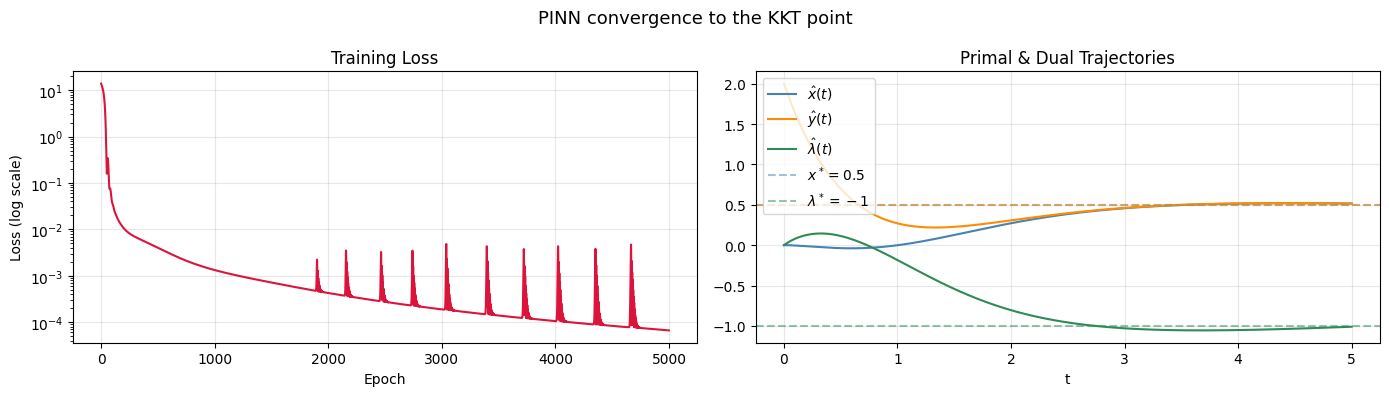

In [5]:
import matplotlib.pyplot as plt

# Evaluate on a fine time grid
t_eval = jnp.linspace(0.0, T, 300)
trajectories = jax.vmap(
    lambda t: model.apply({"params": params}, t)
)(t_eval)

x_traj   = trajectories[:, 0]
y_traj   = trajectories[:, 1]
lam_traj = trajectories[:, 2]

print("Final PINN values (at t = T):")
print(f"  x      = {float(x_traj[-1]):.6f}   (analytical: 0.5)")
print(f"  y      = {float(y_traj[-1]):.6f}   (analytical: 0.5)")
print(f"  lambda = {float(lam_traj[-1]):.6f}   (analytical: -1.0)")

# -- Loss curve --
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].semilogy(loss_history, color='crimson')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (log scale)')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

# -- Trajectories --
axes[1].plot(t_eval, x_traj,   label=r'$\hat{x}(t)$',       color='steelblue')
axes[1].plot(t_eval, y_traj,   label=r'$\hat{y}(t)$',       color='darkorange')
axes[1].plot(t_eval, lam_traj, label=r'$\hat{\lambda}(t)$', color='seagreen')
axes[1].axhline(0.5,  linestyle='--', color='steelblue',  alpha=0.5, label=r'$x^*=0.5$')
axes[1].axhline(0.5,  linestyle='--', color='darkorange', alpha=0.5)
axes[1].axhline(-1.0, linestyle='--', color='seagreen',   alpha=0.5, label=r'$\lambda^*=-1$')
axes[1].set_xlabel('t')
axes[1].set_title('Primal & Dual Trajectories')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('PINN convergence to the KKT point', fontsize=13)
plt.tight_layout()
plt.show()